In [41]:
%pip install -U scikit-learn


In [1]:
%pip install chardet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

In [3]:
# Done to check the what encoding is used in the file
import chardet

with open("spam.csv", "rb") as f:
    result = chardet.detect(f.read())
    
    
encoding_correct= result['encoding']

data= pd.read_csv("spam.csv",encoding=encoding_correct)

In [4]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## Data Preprocessing

In [6]:


##Removing duplicate columns

data= data.drop_duplicates(keep="first")

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5169 non-null   object
 1   v2          5169 non-null   object
 2   Unnamed: 2  43 non-null     object
 3   Unnamed: 3  10 non-null     object
 4   Unnamed: 4  5 non-null      object
dtypes: object(5)
memory usage: 242.3+ KB


In [8]:
# Rename label to target and dropping irrelevant columns

data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

data.rename(columns={"v1":"target", "v2": "text"}, inplace= True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_29828\4178057119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_29828\4178057119.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns={"v1":"target", "v2": "text"}, inplace= True)


In [9]:
# Label encode target coumn(in our cased not needed as already in numerical form)

from sklearn.preprocessing import LabelEncoder

encoder= LabelEncoder()

#.loc or .copy() to ensure you're working with the original DataFrame else  warning occurs because you're modifying a slice of a DataFrame4

data.loc[:, "target"]= encoder.fit_transform(data["target"])

In [10]:
data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## EDA

In [11]:
data["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

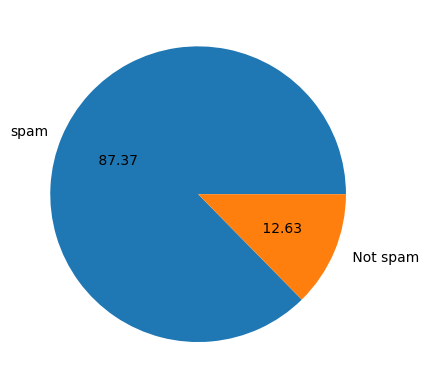

In [12]:
import matplotlib.pyplot as plt
plt.pie(data["target"].value_counts(), labels=["spam", " Not spam"], autopct=" %0.2f" )
plt.show()

# Conclusion: Data is not balanced

In [13]:
# count Number of characters

data.loc[:, "no_of_characters"]= data["text"].apply(len)

C:\Users\Asus\AppData\Local\Temp\ipykernel_29828\2042225976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "no_of_characters"]= data["text"].apply(len)


In [14]:
import nltk
nltk.download("punkt", download_dir="D:/nltk_data")

[nltk_data] Downloading package punkt to D:/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
import nltk
print(nltk.data.path)

['C:\\Users\\Asus/nltk_data', 'c:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data', 'c:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data', 'c:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data', 'C:\\Users\\Asus\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']


In [16]:
import nltk
from nltk.tokenize import TreebankWordTokenizer

# Alternative to nltk.word_tokenize ----> TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()

# Extract number of words
data.loc[:, "no_of_words"]= data["text"].apply(lambda x: len(tokenizer.tokenize(x)))

C:\Users\Asus\AppData\Local\Temp\ipykernel_29828\2657359882.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "no_of_words"]= data["text"].apply(lambda x: len(tokenizer.tokenize(x)))


In [17]:
data.head()

,target,text,no_of_characters,no_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,23
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [18]:
data.describe()

,no_of_characters,no_of_words
count,5169.000000,5169.000000
mean,78.977945,17.695299
std,58.236293,12.672457
min,2.000000,1.000000
25%,36.000000,9.000000
50%,60.000000,14.000000
75%,117.000000,25.000000
max,910.000000,214.000000


In [19]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='no_of_characters', ylabel='Count'>

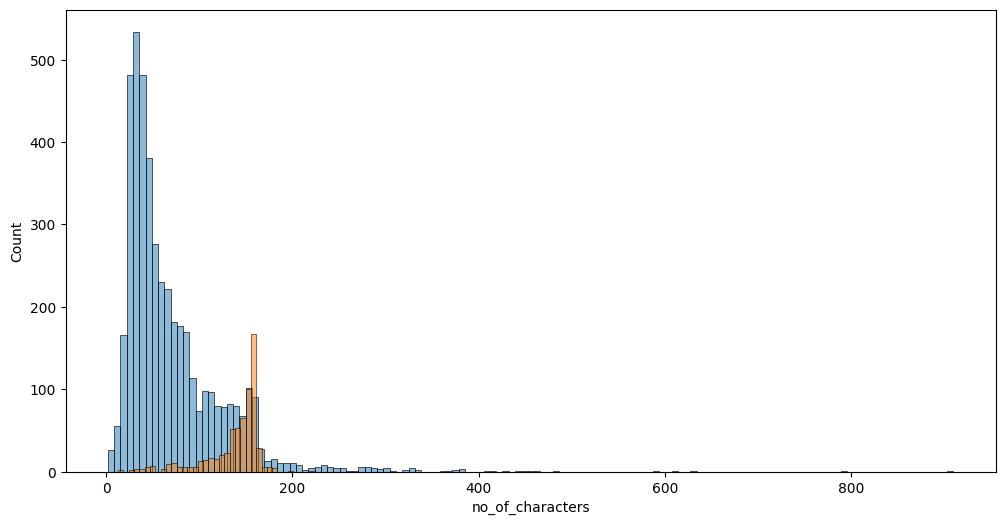

In [20]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(data[data["target"]==0]["no_of_characters"],alpha=0.5, label="Not Spam")
sns.histplot(data[data["target"]==1]["no_of_characters"],alpha=0.5, label="Spam")






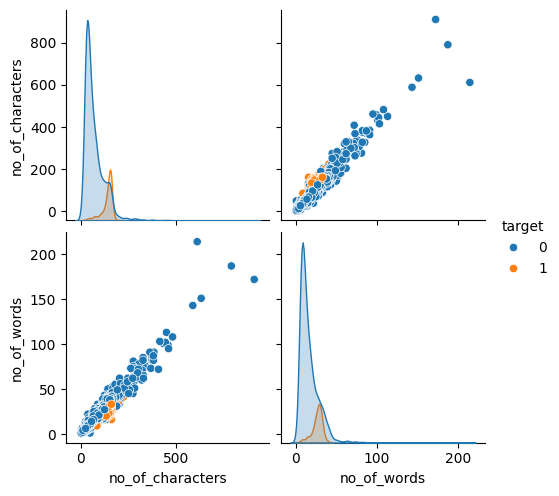

In [21]:
sns.pairplot(data, hue="target")

<Axes: >

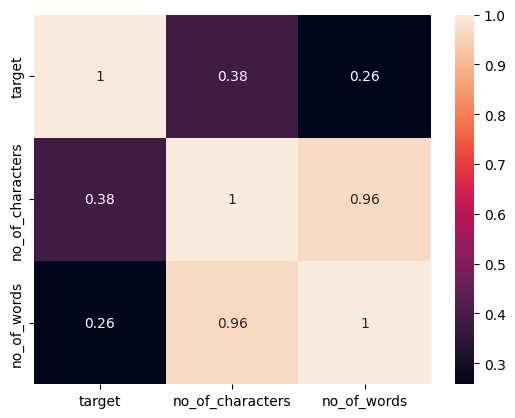

In [22]:
data_copy= data.copy()

data_copy.drop("text", axis=1, inplace= True)

sns.heatmap(data_copy.corr(),annot = True)

# Conclusion High correlation between no_of_characters and no_of_words, so multicollinearity occurs so we will keep only one column

## Data Preprocessing

 ##### a] Lower Case
 ##### b] Tokenize
 ##### c] Special Characters
 ##### d] Remove Stopwords and punctuations
 ##### e] Stemming


In [23]:
from nltk.corpus import stopwords # type: ignore
import string
from nltk.stem import PorterStemmer # type: ignore

In [24]:
def text_transform(data):
    
    # Converting text to lower case
    text= data.lower()
    text= TreebankWordTokenizer().tokenize(text)
    
    
    # Removing special characters
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text=y[:]
    y.clear()
    
    # Removing stopwords and punctuations from text 
    
    for i in text:
        if i not in stopwords.words("english") and string.punctuation:
            y.append(i)
            
    
    text=y[:]
    y.clear()
    
    # Stemming: Stemming is the process of reducing a word to its root or base form. This is done by removing suffixes and prefixes to standardize words with similar meanings. It treats different word forms (e.g., "running," "runs," "ran") as the same base word ("run").
    
    ps= PorterStemmer()
    
    for i in text:
        y.append(ps.stem(i))
            
    return y


In [25]:
text_transform("My love Aditya is Loving his book and ran into running water @##@?")

['love', 'aditya', 'love', 'book', 'ran', 'run', 'water']

In [26]:
data.loc[:, "tranformed_text"]= data["text"].apply(text_transform)

C:\Users\Asus\AppData\Local\Temp\ipykernel_29828\2810267020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "tranformed_text"]= data["text"].apply(text_transform)


In [27]:
data.head()

,target,text,no_of_characters,no_of_words,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,"[go, jurong, point, avail, bugi, n, great, wor..."
1,0,Ok lar... Joking wif u oni...,29,8,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,"[nah, think, goe, usf, live, around, though]"


## Roughwork for Understanding

In [28]:
# Rough for Stopwords

import nltk 

nltk.download("stopwords", download_dir="D:/nltk_data")

from nltk.corpus import stopwords 
stopwords.words("english")[0:10]  # Just printing first 10 stopwords for example

[nltk_data] Downloading package stopwords to D:/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [29]:
#Rough for Punctuation

import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [30]:
# Rough for stemming

from nltk.stem import PorterStemmer

ps= PorterStemmer()
ps.stem("running")

'run'

## Creating Word Cloud

In [31]:
data.head()

,target,text,no_of_characters,no_of_words,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,"[go, jurong, point, avail, bugi, n, great, wor..."
1,0,Ok lar... Joking wif u oni...,29,8,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,"[nah, think, goe, usf, live, around, though]"


In [32]:
%pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


In [33]:
from wordcloud import WordCloud

wc= WordCloud(width=500, height=100, min_font_size=10, background_color="white")


In [34]:
#This line of code ensures that all values in the "transformed_text" column are converted to strings, even if they are lists. 

data.loc[:, "tranformed_text"] = data["tranformed_text"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

# Wordcloud for spam
spam_wc= wc.generate(data[data["target"]==1]["tranformed_text"].str.cat(sep=" "))

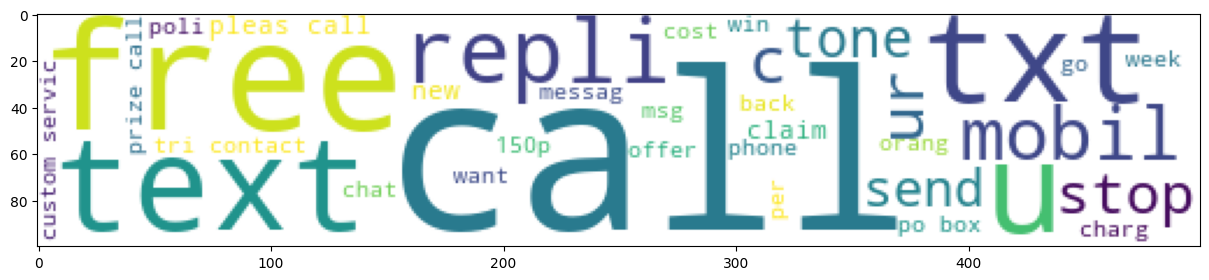

In [35]:
plt.figure(figsize=(15,10))
plt.imshow(spam_wc)

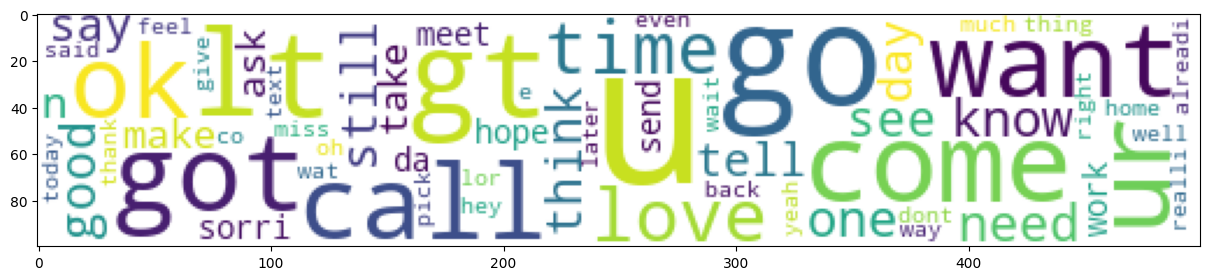

In [36]:
not_spam_wc= wc.generate(data[data["target"]==0]["tranformed_text"].str.cat(sep=" "))

plt.figure(figsize=(15,10))

plt.imshow(not_spam_wc)

In [37]:
spam_corpus = []
for msg in data[data['target'] == 1]['tranformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [38]:
len(spam_corpus)

9339

In [39]:
not_spam_corpus = []
for msg in data[data['target'] == 0]['tranformed_text'].tolist():
    for word in msg.split():
        not_spam_corpus.append(word)

In [40]:
len(not_spam_corpus)

33008

In [44]:
from collections import Counter

df= pd.DataFrame(Counter(spam_corpus).most_common(30))

df.head()

,0,1
0,call,316
1,free,179
2,2,155
3,txt,139
4,text,120


In [ ]:
df_non_spam= pd.DataFrame(Counter(not_spam_corpus).most_common(30))


,0,1
0,u,871
1,go,397
2,get,347
3,gt,288
4,lt,287
5,2,284
6,come,270
7,got,236
8,like,232
9,know,228


## Model 

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

cv= CountVectorizer()

X= cv.fit_transform(data["tranformed_text"]).toarray()

Y=data["target"].values

In [55]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,), dtype=object)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=420)

In [82]:
# Since Y_train and Y_test has a dtype of object, we need to convert them to int64 to avoid issue while traing

Y_train = np.array(Y_train, dtype=np.int64)
Y_test = np.array(Y_test, dtype=np.int64)

In [83]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score


In [84]:
# gaussian Naive Bayes

gnb= GaussianNB()

gnb.fit(X_train, Y_train)

Y_pred1= gnb.predict(X_test)


print(f"Accuracy score for gaussian NAive Byes: {accuracy_score(Y_test, Y_pred1)}") 

print(f"Confusion matrix for gaussian NAive Byes : \n {confusion_matrix(Y_test, Y_pred1)}")

print(f"Precision score for gaussian NAive Byes: {precision_score(Y_test, Y_pred1)}")


Accuracy score for gaussian NAive Byes: 0.8452611218568665
Confusion matrix for gaussian NAive Byes : 
 [[755 146]
 [ 14 119]]
Precision score for gaussian NAive Byes: 0.4490566037735849


In [85]:
mb= MultinomialNB()

mb.fit(X_train, Y_train)

Y_pred2= mb.predict(X_test)

print(f"Accuracy score for Multinomial NAive Byes: {accuracy_score(Y_test, Y_pred2)}") 

print(f"Confusion matrix for Multinomial NAive Byes : \n {confusion_matrix(Y_test, Y_pred2)}")

print(f"Precision score for Multinomial NAive Byes: {precision_score(Y_test, Y_pred2)}")

Accuracy score for Multinomial NAive Byes: 0.9777562862669246
Confusion matrix for Multinomial NAive Byes : 
 [[886  15]
 [  8 125]]
Precision score for Multinomial NAive Byes: 0.8928571428571429


In [86]:
bn= BernoulliNB()

bn.fit(X_train, Y_train)

Y_pred3= bn.predict(X_test)

print(f"Accuracy score for Bernoulli NAive Byes: {accuracy_score(Y_test, Y_pred3)}") 

print(f"Confusion matrix for Bernoulli NAive Byes : \n {confusion_matrix(Y_test, Y_pred3)}")

print(f"Precision score for Bernoulli NAive Byes: {precision_score(Y_test, Y_pred3)}")

Accuracy score for Bernoulli NAive Byes: 0.9709864603481625
Confusion matrix for Bernoulli NAive Byes : 
 [[900   1]
 [ 29 104]]
Precision score for Bernoulli NAive Byes: 0.9904761904761905


### Conclusion: BernoulliNB() has best precision and accuracy

#### Now, instead of Bag of words(Count Vectorizer) we will go with tfidfVectorizer and check our models

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer

tdf= TfidfVectorizer(max_features=3000)

X= tdf.fit_transform(data["tranformed_text"]).toarray()

Y=data["target"].values



In [109]:
# won't use are it is decreasing accuracy

#from sklearn.preprocessing import MinMaxScaler

# Min Max scaler as StandardScaler repurts negative values also

#sc= MinMaxScaler()
#X= sc.fit_transform(X)

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=420)

# Since Y_train and Y_test has a dtype of object, we need to convert them to int64 to avoid issue while traing

Y_train = np.array(Y_train, dtype=np.int64)
Y_test = np.array(Y_test, dtype=np.int64)

In [111]:
# gaussian Naive Bayes

gnb1= GaussianNB()

gnb1.fit(X_train, Y_train)

Y_pred1= gnb1.predict(X_test)


print(f"Accuracy score for gaussian NAive Byes: {accuracy_score(Y_test, Y_pred1)}") 

print(f"Confusion matrix for gaussian NAive Byes : \n {confusion_matrix(Y_test, Y_pred1)}")

print(f"Precision score for gaussian NAive Byes: {precision_score(Y_test, Y_pred1)}")


Accuracy score for gaussian NAive Byes: 0.8375241779497099
Confusion matrix for gaussian NAive Byes : 
 [[755 146]
 [ 22 111]]
Precision score for gaussian NAive Byes: 0.43190661478599224


In [112]:
mb1= MultinomialNB()

mb1.fit(X_train, Y_train)

Y_pred2= mb1.predict(X_test)

print(f"Accuracy score for Multinomial NAive Byes: {accuracy_score(Y_test, Y_pred2)}") 

print(f"Confusion matrix for Multinomial NAive Byes : \n {confusion_matrix(Y_test, Y_pred2)}")

print(f"Precision score for Multinomial NAive Byes: {precision_score(Y_test, Y_pred2)}")

Accuracy score for Multinomial NAive Byes: 0.9777562862669246
Confusion matrix for Multinomial NAive Byes : 
 [[901   0]
 [ 23 110]]
Precision score for Multinomial NAive Byes: 1.0


In [113]:
bn1= BernoulliNB()

bn1.fit(X_train, Y_train)

Y_pred3= bn1.predict(X_test)

print(f"Accuracy score for Bernoulli NAive Byes: {accuracy_score(Y_test, Y_pred3)}") 

print(f"Confusion matrix for Bernoulli NAive Byes : \n {confusion_matrix(Y_test, Y_pred3)}")

print(f"Precision score for Bernoulli NAive Byes: {precision_score(Y_test, Y_pred3)}")

Accuracy score for Bernoulli NAive Byes: 0.9787234042553191
Confusion matrix for Bernoulli NAive Byes : 
 [[900   1]
 [ 21 112]]
Precision score for Bernoulli NAive Byes: 0.9911504424778761


### Multinomial we will choose has it had best precision

Similarly, try with all other Machine Learning Algorithms and check the accuracy and precision




In [114]:
## Improve the model by hyperparameter tuning


# 1] Set max_features parameter for tfidk( max_features = n' means out of n total words, only the top n' words will be vectorized)

# 2] Standardize the data

In [116]:
import pickle

pickle.dump("tkidf", open("vectorizer.pkl", "wb"))

pickle.dump("mb1", open("model.pkl", "wb"))